In [28]:
import os
import mlflow
import mlflow.catboost
import catboost
import json

import numpy as np
import optuna
import pandas as pd
from catboost import CatBoostClassifier, Pool
from optuna.integration import CatBoostPruningCallback
from optuna.samplers import TPESampler
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from mlflow.tracking import MlflowClient

In [2]:
# Настроиваем pandas
# Показывать все столбцы
pd.set_option("display.max_columns", None)
# Отображать полный текст в ячейках столбцов без усечения
pd.set_option("display.max_colwidth", None)

In [3]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
path = f"{PROJECT_ROOT}/mlruns"

# создаём mlruns и .trash, если нет
os.makedirs(os.path.join(path, ".trash"), exist_ok=True)

mlflow.set_tracking_uri(f"file://{path}")
mlflow.set_experiment("spaceship_titanic")

/opt/anaconda3/envs/spaceship_titanic_kaggle/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location=('file:///Users/admin/DataSince/Kaggle competitions/Spaceship '
 'Titanic/mlruns/689233284165520319'), creation_time=1767104868196, experiment_id='689233284165520319', last_update_time=1767104868196, lifecycle_stage='active', name='spaceship_titanic', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [39]:
df_train = pd.read_csv(('../data/processed/train_2'))
df_test = pd.read_csv('../data/processed/test_2')
df_train.shape, df_test.shape

((8693, 55), (4277, 54))

In [40]:
X = df_train.drop(["PassengerId", "Name", "Transported"], axis=1)
y = df_train.Transported
X.shape, y.shape

((8693, 52), (8693,))

In [41]:
X_test = df_test.drop(["PassengerId", "Name"], axis=1)
X_test.shape

(4277, 52)

In [42]:
cat_features = X.select_dtypes(include="object").columns.tolist()

X[cat_features] = X[cat_features].astype(str)
X_test[cat_features] = X_test[cat_features].astype(str)

In [43]:
run_name = "catboost_cv5_baseline_54features"
test_predict_list = []

train_features_list= X.columns.to_list()
proba_oof = np.zeros(len(y))

params = {
    'loss_function': "Logloss",
    'eval_metric': "AUC",
    'random_state': 42
}
n_splits = 5
auc_scores = []
split_random = 0

# Создадим словарь для накопления важности признаков по каждому фолду
importances_dict = {col: [] for col in X.columns}

kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=split_random)

with mlflow.start_run(run_name=run_name):
    mlflow.log_param("split_random", split_random)
    
    # логируем списки фич как артефакты (в json)
    mlflow.log_text(
        json.dumps(train_features_list, ensure_ascii=False, indent=2),
        artifact_file="train_features.json",
    )
    mlflow.log_text(
        json.dumps(list(cat_features), ensure_ascii=False, indent=2),
        artifact_file="cat_features.json",
    )

    # логируем гиперпараметры
    mlflow.log_params(params)
    mlflow.log_param("n_splits", n_splits) 

    for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = CatBoostClassifier(
            **params,
            cat_features=cat_features,
            verbose=False)
        model.fit(X_train, y_train)

        # Сохраним важности признаков в словаре
        importances = model.get_feature_importance()
        for col, imp in zip(X.columns, importances, strict=True):
            importances_dict[col].append(imp)

        val_pred = model.predict_proba(X_val)[:, 1]
        proba_oof[val_idx] = val_pred 
        
        auc = roc_auc_score(y_val, val_pred)
        auc_scores.append(auc)
        mlflow.log_metric(f"fold{fold}_auc", float(auc))
        print(f"fold{fold}_auc", float(auc))

        test_pred = model.predict_proba(X_test)[:, 1]
        test_predict_list.append(test_pred)

        
    cv_mean = float(np.mean(auc_scores))
    cv_std = float(np.std(auc_scores))

    mlflow.log_metric("cv_auc_mean", cv_mean)
    mlflow.log_metric("cv_auc_std", cv_std)

    features = importances_dict.keys()
    values = sorted(list([np.mean(v) for v in importances_dict.values()]))
    aggregated_importances = dict(zip(features, values))

    mlflow.log_text(
        json.dumps(aggregated_importances, ensure_ascii=False, indent=2),
        artifact_file="feature_importances_mean.json",
    )

    print("cv_mean, cv_std:", cv_mean, cv_std)

    thresholds = np.linspace(0, 1, 1001)
    accs = []
    
    for thr in thresholds:
        y_pred = (proba_oof >= thr).astype(int)
        accs.append(accuracy_score(y, y_pred))
    
    best_thr = thresholds[np.argmax(accs)]
    best_acc = max(accs)
    print("Best thr, best acc:", best_thr, best_acc)
    
    mlflow.log_param("best_thr", best_thr)
    mlflow.log_metric("best_acc", best_acc)

fold1_auc 0.9064998386217771
fold2_auc 0.9083173277882717
fold3_auc 0.9108993793552278
fold4_auc 0.8999516636318491
fold5_auc 0.9043337195828505
cv_mean, cv_std: 0.9060003857959952 0.003714367437376888
Best thr, best acc: 0.496 0.8173242839065915


In [44]:
exp = mlflow.get_experiment_by_name("spaceship_titanic")
df = mlflow.search_runs([exp.experiment_id], filter_string=f'tags.mlflow.runName = "{run_name}"')
run_id = df.iloc[0]["run_id"]
print(run_id)

62a155e04a124612ba65e126c33ed813


In [50]:
test_acc = 0.80851 # скопировал из Kaggle

client = MlflowClient()
client.log_metric(run_id, "test_acc", float(test_acc))

In [51]:
print("Acc at 0.5:", accuracy_score(y, proba_oof >= 0.5))
print(f"Acc at {best_thr}:", accuracy_score(y, proba_oof >= best_thr))

Acc at 0.5: 0.8169791786494881
Acc at 0.496: 0.8173242839065915


In [46]:
# test_predict_list: список из n_folds массивов длины n_test
# auc_scores: список AUC по фолдам, длина n_folds
# best_thr: найденный порог по proba_oof

test_predict_list = [np.array(p) for p in test_predict_list]
auc_scores = np.array(auc_scores, dtype=float)

# нормируем веса
weights = auc_scores / auc_scores.sum()
print(weights)

# (n_folds, n_test)
test_preds_stack = np.vstack(test_predict_list)

# взвешенный ансамбль по тесту
test_pred_weighted = np.average(test_preds_stack, axis=0, weights=weights) 

# бинарные предикты по найденному порогу
test_pred_bool = (test_pred_weighted >= best_thr).astype(bool)
test_pred_bool

[0.20011025 0.20051147 0.20108146 0.19866474 0.19963208]


array([ True, False,  True, ...,  True,  True,  True])

In [47]:
submision = df_test[["PassengerId"]].copy() 
submision["Transported"] = test_pred_bool
submision.to_csv("../predictions/submission_2.csv", index=False)
submision.shape

(4277, 2)

In [48]:
submision.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


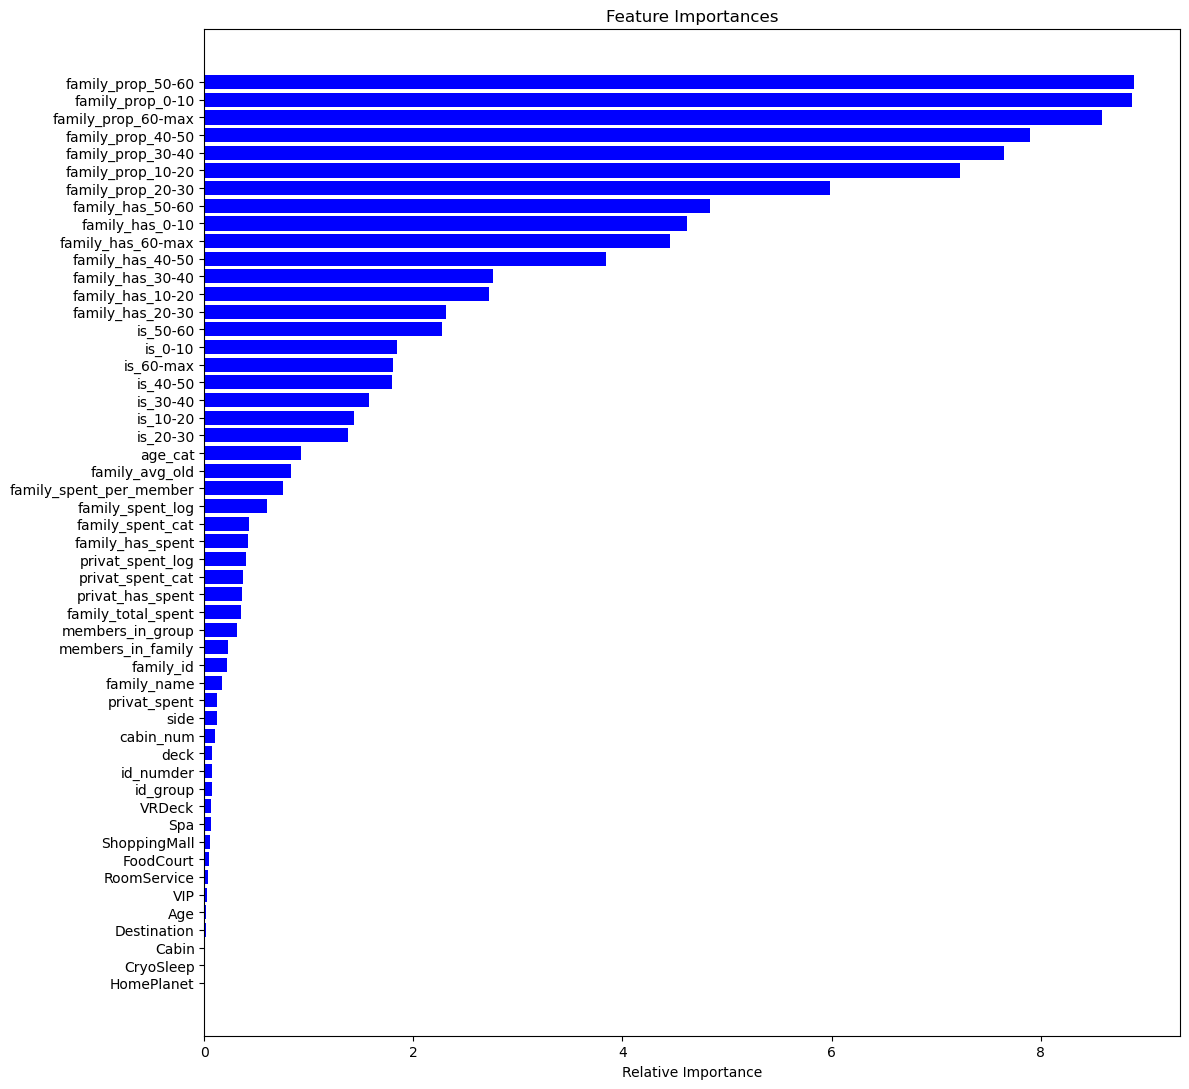

In [49]:
# Визуализируем важности признаков
features = importances_dict.keys()
values = sorted(list([np.mean(v) for v in importances_dict.values()]))

plt.figure(figsize=(12, 11))
plt.barh(features, values, color="blue")
plt.xlabel("Relative Importance")
plt.title("Feature Importances")
# plt.gca().invert_yaxis()  # Самый важный сверху
plt.tight_layout()
plt.show()